# Notebook for XGBoost and SHAPLY calculation

In [4]:
import pandas as pd
import importlib
from XGBoost import xgboost_machine_learning

importlib.reload(xgboost_machine_learning)

<module 'XGBoost.xgboost_machine_learning' from 'C:\\Users\\Minh\\Desktop\\Psycho Arbeit\\Psycho_DataspellProjekt\\XGBoost\\xgboost_machine_learning.py'>

#### Machine Learning Variables

In [2]:
# ===========================
# 🔧 Global Notebook Settings
# ===========================
my_target_column = "How happy are you?"
my_test_size = 0.2
my_random_state = 42

# Model-specific hyperparameters (baseline defaults)
my_n_estimators = 100
my_max_depth = None

# SHAP settings
my_number_of_shaply_rows = 5000
my_number_header_rows = 150

##### Model 1A Optimized

In [12]:
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')

model_1A_optimized, shap_results_1A_optimized = xgboost_machine_learning.run_xgb_gridsearch_and_shap(
    df=data,
    target_column=my_target_column,
    test_size=my_test_size,
    random_state=my_random_state,
    cv_folds=3,
    shap_rows=my_number_of_shaply_rows,
    number_header_rows=my_number_header_rows
)



Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
✅ Test RMSE: 1.2548
✅ Test R²: 0.4491
🔍 Starting SHAP for 5000 rows...


100%|██████████| 1225/1225 [00:28<00:00, 43.68it/s]


Top SHAP features:
                                             Questions     Value  Direction
119     How satisfied with present standard of living?  0.329734  -0.000634
121                    How satisfied with family life?  0.323079  -0.011253
123                    How satisfied with social life?  0.184874  -0.001936
122                         How satisfied with health?  0.096962   0.006327
30                                    Health condition  0.096504   0.007491
..                                                 ...       ...        ...
12                                Education - 3 groups  0.000000   0.000000
81   How much tension between different religious g...  0.000000   0.000000
53                          Access to postal services?  0.000000   0.000000
65   I or someone else in household used child care...  0.000000   0.000000
68           Child care used in 12 months - don't know  0.000000   0.000000

[150 rows x 3 columns]


In [13]:
# Save results
shap_results_1A_optimized.to_csv("Results/shap_results_1A_opzimized.csv", index=False)

##### Model 1B - No 'How satisfied with...' questions - Hyperparameter optimized

In [9]:
# Load data
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')
my_target_column = 'How happy are you?'
print("Shape before: ", data.shape)

# Drop 'How satisfied with...' columns
# They have too much predictive value and there are similar questions
# e.g. "Health condition", "Quality of education system?", "Feel left out of sociey?"
columns_to_remove = [
    'How satisfied with present standard of living?',
    'How satisfied with family life?',
    'How satisfied with social life?',
    'How satisfied with health?',
    'How satisfied with economic situation in the country?',
    'How satisfied with accommodation?',
    'How satisfied with education?'
]
data.drop(columns=columns_to_remove, inplace=True, errors='ignore')
print("Shape after: ", data.shape)

model_1B_optimized, shap_results_1B_optimized = xgboost_machine_learning.run_xgb_gridsearch_and_shap(
    df=data,
    target_column=my_target_column,
    test_size=my_test_size,
    random_state=my_random_state,
    cv_folds=3,
    shap_rows=my_number_of_shaply_rows,
    number_header_rows=my_number_header_rows
)

Shape before:  (6122, 168)
Shape after:  (6122, 162)
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
✅ Test RMSE: 1.4034
✅ Test R²: 0.3108
🔍 Starting SHAP for 5000 rows...


100%|██████████| 1225/1225 [00:24<00:00, 49.86it/s]


Top SHAP features:
                                             Questions     Value  Direction
30                                    Health condition  0.218379   0.014786
115  I generally feel that what I do in life is wor...  0.134750  -0.010004
118                      How satisfied with education?  0.129289  -0.006110
94   Can't find the way because life has become so ...  0.125171  -0.005352
116     I feel I am free to decide how to live my life  0.115504  -0.006746
..                                                 ...       ...        ...
144                                     Country_Latvia  0.000000   0.000000
142                                      Country_Italy  0.000000   0.000000
141                                    Country_Ireland  0.000000   0.000000
140                                    Country_Iceland  0.000000   0.000000
137                                    Country_Germany  0.000000   0.000000

[150 rows x 3 columns]


In [11]:
# Save results
shap_results_1B_optimized.to_csv("Results/shap_results_1B_opzimized.csv", index=False)

# Plots

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

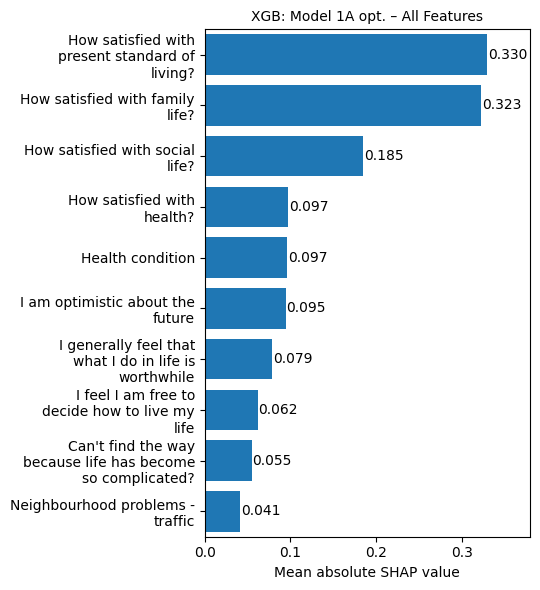

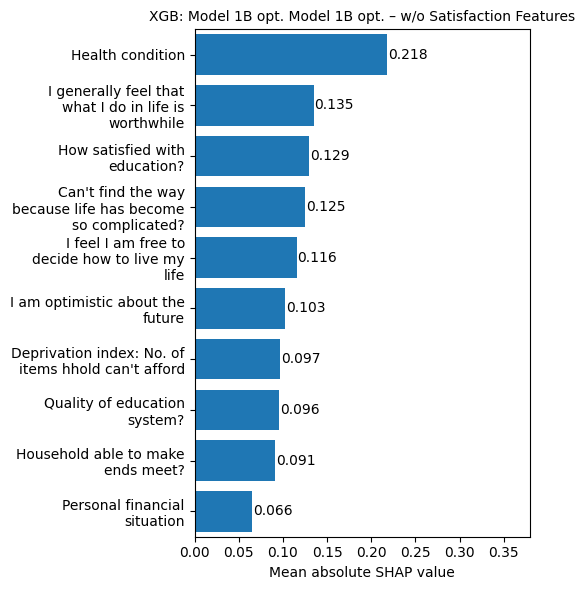

In [3]:
# Load Data
df_1A = pd.read_csv("Results/shap_results_1A_opzimized.csv")
df_1B = pd.read_csv("Results/shap_results_1B_opzimized.csv")

def plot_shap_large(df, title, max_questions=None):
    df_sorted = df.sort_values(by="Value", ascending=True).reset_index(drop=True)
    if max_questions:
        df_sorted = df_sorted.tail(max_questions).reset_index(drop=True)

    df_sorted["Questions"] = df_sorted["Questions"].apply(lambda x: "\n".join(textwrap.wrap(x, width=25)))

    n = len(df_sorted)
    plt.figure(figsize=(5.5, n * 0.6))
    bars = plt.barh(df_sorted["Questions"], df_sorted["Value"])

    # title
    plt.xlabel("Mean absolute SHAP value", color='black', fontsize=10)
    plt.title(title, color='black', fontsize=10)

    xlim_max = max(
        df_1A["Value"].max(),
        df_1B["Value"].max()
    )
    plt.xlim(0, xlim_max+0.05)

    # Display values in the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.3f}",
                 va='center', fontsize=10)

    plt.ylim(-0.5, n - 0.5)
    plt.tight_layout()
    plt.show()

# Show plots
plot_shap_large(df_1A, "XGB: Model 1A opt. – All Features", max_questions=10)
plot_shap_large(df_1B, "XGB: Model 1B opt. Model 1B opt. – w/o Satisfaction Features", max_questions=10)
plt.show()